<a href="https://colab.research.google.com/github/zixian0821-zoe/stochastic_search_and_optimization/blob/main/exercises_00a_00d_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

RNG_SEED = 20260421
np.random.seed(RNG_SEED)

In [ ]:
def P_closed(t1, t2, t3, s=6, sp=16, a=0.0, b=10.0):
    c = (t1 - s)**2 + (t2 - s)**2 + 0.01 * (t3 - sp)**4
    tau = t1 * t2
    if c >= b:
        P = 0.0
    elif a >= c:
        P = 1.0 + (tau / (b - a)) * (math.exp(-(b - c)/tau) - math.exp(-(a - c)/tau))
    else:
        P = (b - c) / (b - a) + (tau / (b - a)) * (math.exp(-(b - c)/tau) - 1.0)
    return P, c, tau

In [ ]:
S, Sp = 6, 16
best = (float("inf"), None)
for t1 in range(1, 21):
    for t2 in range(1, 21):
        for t3 in range(1, 21):
            L = (t1 - S)**2 + t1*t2 + (t2 - S)**2 + 0.01*(t3 - Sp)**4
            if L < best[0]:
                best = (L, (t1, t2, t3))
print(f"theta*={best[1]}, L*={best[0]}")

theta*=(4, 4, 16), L*=24.0


In [ ]:
cases = [
    ("theta*",     (4, 4, 16),   0,   10),
    ("theta*",     (4, 4, 16),   0,  100),
    ("theta*",     (4, 4, 16),   0, 1000),
    ("[12,12,12]", (12,12,12), 100, 1000),
]
print(f"{'label':<12}{'a':>6}{'b':>6}{'c':>10}{'tau':>6}{'P':>12}")
for lbl, th, a, b in cases:
    P, c, tau = P_closed(*th, a=a, b=b)
    print(f"{lbl:<12}{a:>6}{b:>6}{c:>10.2f}{tau:>6}{P:>12.6f}")

label            a     b         c   tau           P
theta*           0    10      8.00    16    0.011995
theta*           0   100      8.00    16    0.760509
theta*           0  1000      8.00    16    0.976000
[12,12,12]     100  1000     74.56   144    0.866169


In [ ]:
def P_mc(t1, t2, t3, s=6, sp=16, a=0.0, b=10.0, N=2_000_000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    c = (t1 - s)**2 + (t2 - s)**2 + 0.01 * (t3 - sp)**4
    V = rng.exponential(scale=t1, size=N)
    U = rng.uniform(a, b, size=N)
    y = c + V * t2
    return float(np.mean(y <= U))


rng = np.random.default_rng(RNG_SEED)
print(f"{'label':<12}{'a':>6}{'b':>6}{'P_closed':>12}{'P_MC':>12}")
for lbl, th, a, b in cases:
    P, _, _ = P_closed(*th, a=a, b=b)
    Pmc = P_mc(*th, a=a, b=b, rng=rng)
    print(f"{lbl:<12}{a:>6}{b:>6}{P:>12.6f}{Pmc:>12.6f}")

label            a     b    P_closed        P_MC
theta*           0    10    0.011995    0.012009
theta*           0   100    0.760509    0.760541
theta*           0  1000    0.976000    0.976229
[12,12,12]     100  1000    0.866169    0.866195


In [ ]:
p = 200
theta_star = np.ones(p)


def L_true(theta):
    if theta.ndim == 1:
        s = float(theta.sum())
        r = theta + s / p - 2.0
        return float(np.sum(r * r))
    s = theta.sum(axis=-1, keepdims=True)
    r = theta + s / p - 2.0
    return np.sum(r * r, axis=-1)


def grad_L(theta):
    s1 = theta.sum()
    r = theta + s1 / p - 2.0
    s2 = r.sum()
    return 2.0 * (r + s2 / p)


th0 = 10.0 * np.ones(p)
print(f"L(10*1)={L_true(th0):.2f}, ||grad||={np.linalg.norm(grad_L(th0)):.4f}, "
      f"||th0-th*||={np.linalg.norm(th0 - theta_star):.4f}")

L(10*1)=64800.00, ||grad||=1018.2338, ||th0-th*||=127.2792


In [ ]:
def dspsa_gradient(theta_hat, rng, sigma=1.0):
    pi_th = np.floor(theta_hat) + 0.5
    Delta = rng.choice([-1.0, 1.0], size=theta_hat.shape)
    th_plus  = pi_th + 0.5 * Delta
    th_minus = pi_th - 0.5 * Delta
    y_plus  = L_true(th_plus)  + sigma * rng.standard_normal()
    y_minus = L_true(th_minus) + sigma * rng.standard_normal()
    return (y_plus - y_minus) * Delta

In [ ]:
N_meas = 20_000
iters_total = N_meas // 2
A_gain = int(0.1 * iters_total)

target_step = 0.002 * np.linalg.norm(th0)

rng_cal = np.random.default_rng(2026)
g_samples = np.stack(
    [dspsa_gradient(th0, rng_cal) for _ in range(100)],
    axis=0,
)
mean_abs_g_i = float(np.mean(np.abs(g_samples)))
mean_gnorm   = float(np.mean(np.linalg.norm(g_samples, axis=1)))

a_for_alpha = {}
for alpha in (0.501, 1.0):
    a_for_alpha[alpha] = target_step * (1 + A_gain)**alpha / mean_abs_g_i

print(f"A={A_gain}, target={target_step:.4f}, "
      f"E|g_i|={mean_abs_g_i:.3f}, E||g||={mean_gnorm:.2f}")
for alpha, a_val in a_for_alpha.items():
    a0 = a_val / (1 + A_gain)**alpha
    print(f"alpha={alpha}, a={a_val:.6g}, a0={a0:.6g}")

A=1000, target=0.2828, E|g_i|=921.350, E||g||=13029.85
alpha=0.501, a=0.00977998, a0=0.000306987
alpha=1.0, a=0.307294, a0=0.000306987


In [ ]:
def run_dspsa(alpha, a_val, A_gain, iters, theta0, theta_star, rng):
    theta_hat = theta0.copy()
    err_round = np.empty(iters + 1)
    err_raw   = np.empty(iters + 1)
    err_round[0] = np.linalg.norm(np.rint(theta_hat) - theta_star)
    err_raw[0]   = np.linalg.norm(theta_hat - theta_star)
    for k in range(iters):
        ak = a_val / (k + 1 + A_gain)**alpha
        g = dspsa_gradient(theta_hat, rng)
        theta_hat = theta_hat - ak * g
        err_round[k + 1] = np.linalg.norm(np.rint(theta_hat) - theta_star)
        err_raw[k + 1]   = np.linalg.norm(theta_hat - theta_star)
    L_round_term = L_true(np.rint(theta_hat))
    return err_round, err_raw, L_round_term


reps = 20
denom_norm = np.linalg.norm(th0 - theta_star)
denom_L    = L_true(th0) - L_true(theta_star)

results = {}
for alpha in (0.501, 1.0):
    a_val = a_for_alpha[alpha]
    err_r_stack = np.zeros((reps, iters_total + 1))
    err_w_stack = np.zeros((reps, iters_total + 1))
    L_term      = np.zeros(reps)
    for r in range(reps):
        rr = np.random.default_rng(1_000_003 + 7919 * r + int(alpha * 1000))
        er, ew, Lr = run_dspsa(alpha, a_val, A_gain, iters_total,
                               th0, theta_star, rr)
        err_r_stack[r] = er
        err_w_stack[r] = ew
        L_term[r] = Lr
    results[alpha] = dict(
        err_r_mean = err_r_stack.mean(axis=0),
        err_w_mean = err_w_stack.mean(axis=0),
        err_r_term = err_r_stack[:, -1].mean(),
        err_w_term = err_w_stack[:, -1].mean(),
        L_term     = L_term.mean(),
        a_val      = a_val,
    )

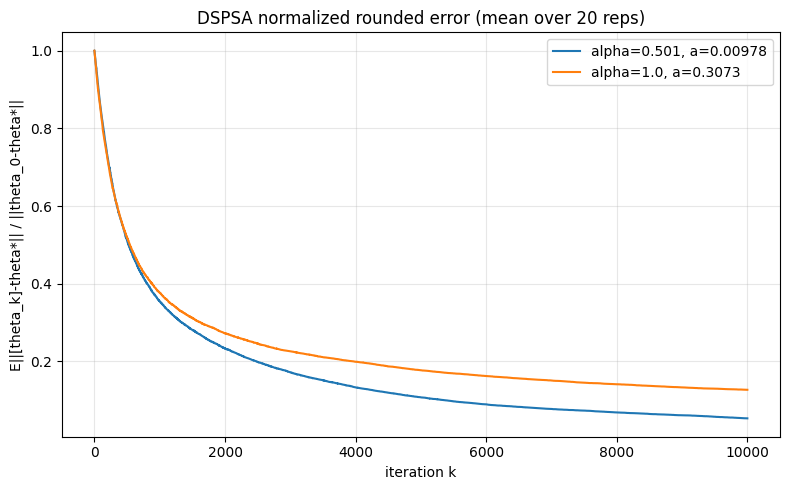

In [ ]:
plt.figure(figsize=(8, 5))
for alpha in (0.501, 1.0):
    curve = results[alpha]["err_r_mean"] / denom_norm
    plt.plot(np.arange(iters_total + 1), curve,
             label=f"alpha={alpha}, a={results[alpha]['a_val']:.4g}")
plt.xlabel("iteration k")
plt.ylabel("E||[theta_k]-theta*|| / ||theta_0-theta*||")
plt.title("DSPSA normalized rounded error (mean over 20 reps)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("dspsa_error.png", dpi=150)
plt.show()

In [ ]:
print(f"{'alpha':>6} {'a':>12} {'round_norm':>14} {'raw_norm':>14} {'loss_norm':>14}")
for alpha in (0.501, 1.0):
    R = results[alpha]
    n1 = R["err_r_term"] / denom_norm
    n2 = R["err_w_term"] / denom_norm
    n3 = (R["L_term"] - L_true(theta_star)) / denom_L
    print(f"{alpha:>6} {R['a_val']:>12.4g} {n1:>14.4f} {n2:>14.4f} {n3:>14.4f}")

 alpha            a     round_norm       raw_norm      loss_norm
 0.501      0.00978         0.0536         0.0411         0.0007
   1.0       0.3073         0.1271         0.1210         0.0041
